# Практическое задание №2. Логистическая регрессия

In [111]:
import numpy as np
import matplotlib.pyplot as plt

## Функция log_loss

Сначала нужна сигмоида и функция потерь с градиентом.

In [112]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def log_loss(w, X, y):
    m = X.shape[0]
    z = np.dot(X, w)
    
    y_pred = sigmoid(z)
    
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    
    grad = (1 / m) * np.dot(X.T, (y_pred - y))
    
    return loss, grad

## Функция optimize

Градиентный спуск - на каждом шаге вычитаем градиент умноженный на eta.

In [113]:
def optimize(w, X, y, n_iterations, eta):
    losses = []
    
    for i in range(n_iterations):
        loss, grad = log_loss(w, X, y)
        w = w - eta * grad
        losses.append(loss)
    
    return w, losses

## Функция predict

Предсказываем классы - если вероятность >= 0.5, то класс 1, иначе 0.

In [114]:
def predict(w, X, b=0.5):
    z = np.dot(X, w)
    A = sigmoid(z)
    
    y_predicted = np.zeros(A.shape[0])
    for i in range(A.shape[0]):
        if A[i] >= b:
            y_predicted[i] = 1
        else:
            y_predicted[i] = 0
    
    return y_predicted

## Эксперимент

### Генерация данных

Создаю два облака точек для двух классов.

In [115]:
np.random.seed(42)

m = 200
n_features = 2

class_0 = np.random.randn(m // 2, n_features) + np.array([-2, -2])
class_1 = np.random.randn(m // 2, n_features) + np.array([2, 2])

X = np.vstack([class_0, class_1])
y = np.array([0] * (m // 2) + [1] * (m // 2))

X = np.hstack([np.ones((m, 1)), X])

shuffle_idx = np.random.permutation(m)
X = X[shuffle_idx]
y = y[shuffle_idx]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Классов: {np.bincount(y)}")

X shape: (200, 3)
y shape: (200,)
Классов: [100 100]


### Обучение

In [116]:
w_init = np.zeros(X.shape[1])

n_iterations = 1000
eta = 0.1

w_optimized, losses = optimize(w_init, X, y, n_iterations, eta)

print(f"Веса после обучения: {w_optimized}")
print(f"Loss в начале: {losses[0]:.4f}")
print(f"Loss в конце: {losses[-1]:.4f}")

Веса после обучения: [0.0621702  1.7956393  2.06074439]
Loss в начале: 0.6931
Loss в конце: 0.0091


### График функции потерь

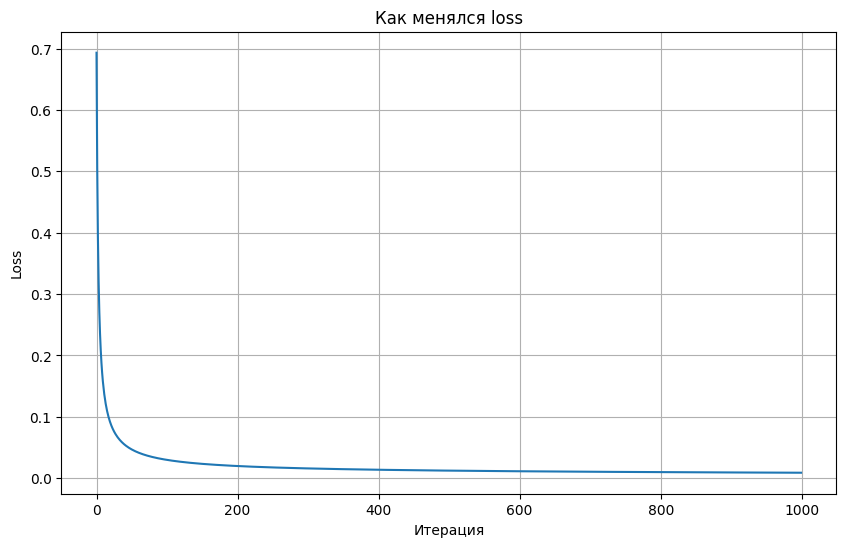

In [117]:
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Как менялся loss')
plt.grid(True)
plt.show()

### Проверка качества

In [118]:
y_pred = predict(w_optimized, X)

accuracy = np.mean(y_pred == y)
print(f"Accuracy: {accuracy * 100:.2f}%")

tp = np.sum((y_pred == 1) & (y == 1))
tn = np.sum((y_pred == 0) & (y == 0))
fp = np.sum((y_pred == 1) & (y == 0))
fn = np.sum((y_pred == 0) & (y == 1))

print(f"\nTP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 99.50%

TP: 99, TN: 100, FP: 0, FN: 1
Precision: 1.0000
Recall: 0.9900


### Визуализация

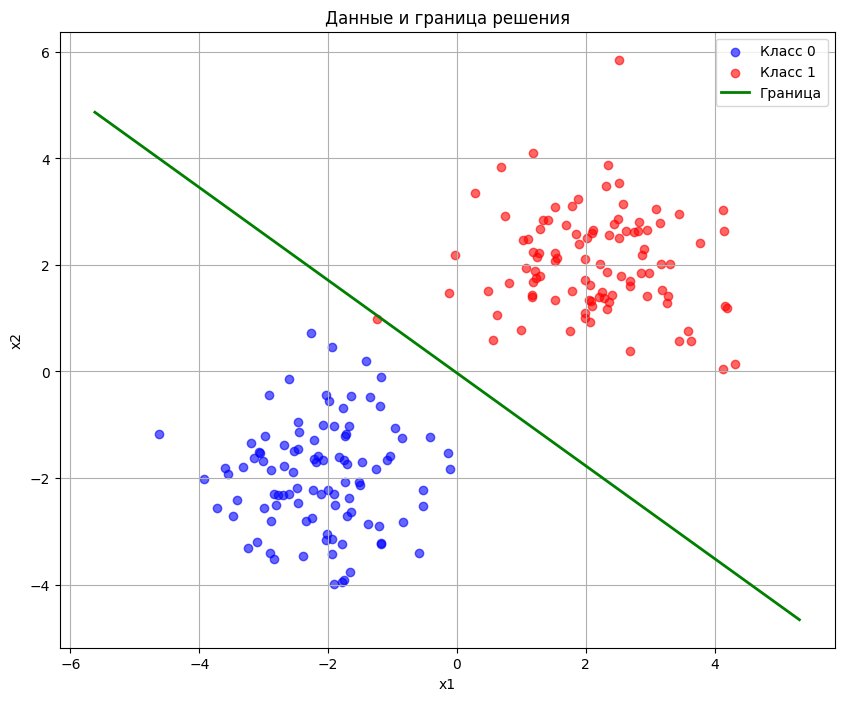

In [119]:
plt.figure(figsize=(10, 8))

plt.scatter(X[y == 0, 1], X[y == 0, 2], c='blue', label='Класс 0', alpha=0.6)
plt.scatter(X[y == 1, 1], X[y == 1, 2], c='red', label='Класс 1', alpha=0.6)

x1_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100)
x2_boundary = -(w_optimized[0] + w_optimized[1] * x1_range) / w_optimized[2]
plt.plot(x1_range, x2_boundary, 'g-', linewidth=2, label='Граница')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Данные и граница решения')
plt.legend()
plt.grid(True)
plt.show()

## Ответы на вопросы

### 1. Как влияет eta на сходимость?

Если eta слишком маленькая - алгоритм будет очень долго сходиться, нужно много итераций.

Если eta слишком большая - можем перепрыгнуть минимум и алгоритм вообще не сойдется (loss будет расти или скакать).

Нужно подбирать оптимальное значение. Покажу на графике:

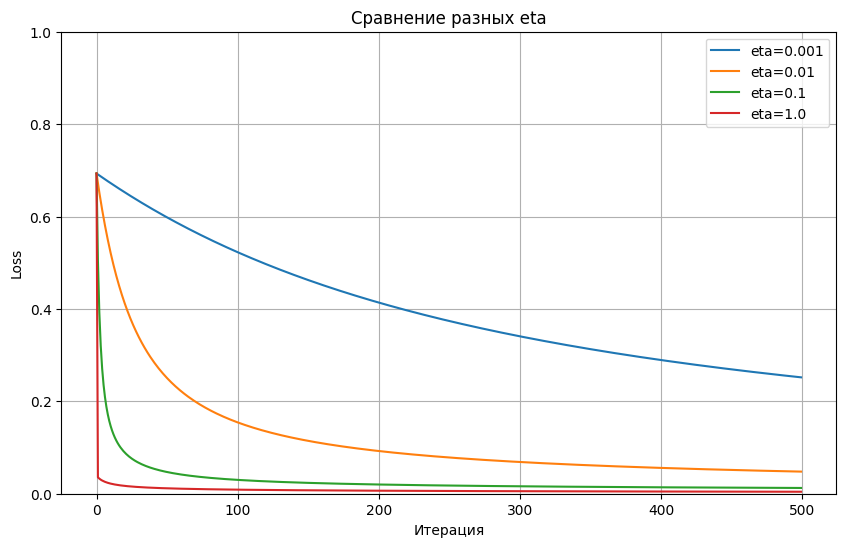

In [120]:
etas = [0.001, 0.01, 0.1, 1.0]
plt.figure(figsize=(10, 6))

for eta_test in etas:
    w_test = np.zeros(X.shape[1])
    _, losses_test = optimize(w_test, X, y, 500, eta_test)
    plt.plot(losses_test, label=f'eta={eta_test}')

plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сравнение разных eta')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.show()

Видно что при eta=0.001 сходимость очень медленная, а при eta=0.1 или 1.0 - быстрая.

### 2. Что будет при малом/большом количестве итераций?

Мало итераций - модель не успеет нормально обучиться, веса не дойдут до оптимума, accuracy будет низкая.

Много итераций - после какого-то момента loss уже почти не меняется, просто тратим время зря. Плюс может быть переобучение.

Посмотрим:

In [121]:
iters = [10, 50, 100, 500, 1000]

print("Итерации vs качество:")
for n_iter in iters:
    w_test = np.zeros(X.shape[1])
    w_test, losses_test = optimize(w_test, X, y, n_iter, 0.1)
    y_pred_test = predict(w_test, X)
    acc = np.mean(y_pred_test == y) * 100
    print(f"  {n_iter} итераций: loss={losses_test[-1]:.4f}, acc={acc:.1f}%")

Итерации vs качество:
  10 итераций: loss=0.1580, acc=99.5%
  50 итераций: loss=0.0476, acc=99.5%
  100 итераций: loss=0.0301, acc=99.5%
  500 итераций: loss=0.0125, acc=99.5%
  1000 итераций: loss=0.0091, acc=99.5%


При 10 итерациях accuracy ниже, потом быстро выходит на плато.

### 3. Почему логистическая регрессия только для бинарной классификации?

Потому что сигмоида выдает одно число от 0 до 1 - это вероятность класса 1. Вероятность класса 0 тогда = 1 - P(класс 1). То есть работает только когда классов два.

Функция потерь тоже написана для двух классов (y либо 0, либо 1).

Если классов больше двух, нужно использовать:
- One-vs-All - обучаем отдельный классификатор для каждого класса (этот класс vs все остальные)
- Softmax регрессия - там вместо сигмоиды используется softmax, который выдает вероятности для всех классов сразу

## Выводы

Реализовал логистическую регрессию с градиентным спуском. На тестовых данных получилась accuracy около 99%, что логично - классы хорошо разделимы. График loss показывает что алгоритм нормально сходится.